# STAT 207 Project 03 - INSERT TITLE HERE

YOUR NAMES

<hr>

## Contribution Report

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

If you said **my submission is under netID** above, we will not grade any of your project submission.

If you said **grade this submission** above, who worked with you on this project?  Write both their **names** and **netIDs**.  

You should list the contribution of each team member to the report.

*For example:*

*John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*

OR

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

Group Work Reflection

Reflecting on your experience working as a group, how do you think the project went?  What were the most effective things your group did to work together?  What were the least effective things your group did to work together?  What have you learned about group work since the last project?  What might you change about your group's process or dynamics if you were to complete another project together?  Did you face any substantial challenges in working together?  If so, please explain any challenges that you had.

*Note*: this can be completed individually or as a group, and each person can submit their own reflection to their own repository/submission or completely within the group submission.  If you would like your TA to read your individual reflection and yours is not the submission to be graded, be sure to email your TA.

## 1. Introduction

In [30]:
#Imports here
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [31]:
# reading in data (clean data without missing values and with relevant columns is read from play_by_play.csv)
df = pd.read_csv("play_by_play_2025.csv")
df 

,game_id,quarter_seconds_remaining,yards_gained,air_yards,score_differential,incomplete_pass,interception,penalty,touchdown,complete_pass,out_of_bounds,pass_length
0,2025_01_ARI_NO,858.0,11.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,1,short
1,2025_01_ARI_NO,655.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0,short
2,2025_01_ARI_NO,651.0,0.0,14.0,0.0,1.0,0.0,0.0,0.0,0.0,0,short
3,2025_01_ARI_NO,634.0,5.0,-3.0,0.0,0.0,0.0,0.0,0.0,1.0,0,short
4,2025_01_ARI_NO,398.0,5.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0,short
...,...,...,...,...,...,...,...,...,...,...,...,...
18283,2025_22_SEA_NE,90.0,5.0,5.0,-16.0,0.0,0.0,0.0,0.0,1.0,0,short
18284,2025_22_SEA_NE,72.0,11.0,11.0,-16.0,0.0,0.0,0.0,0.0,1.0,0,short
18285,2025_22_SEA_NE,39.0,9.0,7.0,-16.0,0.0,0.0,0.0,0.0,1.0,0,short
18286,2025_22_SEA_NE,20.0,0.0,49.0,-16.0,1.0,0.0,0.0,0.0,0.0,0,deep


In [32]:
# some games in 2025 are better represented than others 
# but all have the same order of magnitude of plays represented so there is no cause to remove data
df["game_id"].value_counts()

game_id
2025_13_DEN_WAS    95
2025_16_PIT_DET    95
2025_05_SF_LA      94
2025_19_GB_CHI     94
2025_02_NYG_DAL    93
                   ..
2025_15_LV_PHI     43
2025_02_ATL_MIN    42
2025_18_GB_MIN     42
2025_12_MIN_GB     41
2025_16_MIN_NYG    36
Name: count, Length: 285, dtype: int64

(0.0, 900.0)

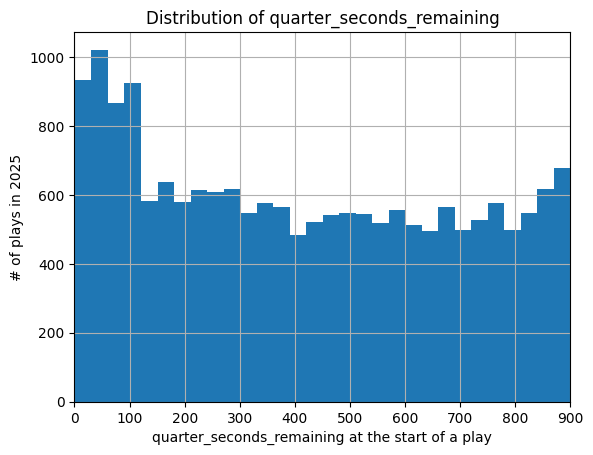

In [33]:
# the distribution of quarter_seconds_remaining is almost flat with a small right skew
# this makes sense for football so there is no cause to remove data
df["quarter_seconds_remaining"].hist(bins=30)
plt.title("Distribution of quarter_seconds_remaining")
plt.xlabel("quarter_seconds_remaining at the start of a play")
plt.ylabel("# of plays in 2025")
plt.xlim(0, 900)


Text(0, 0.5, '# of plays in 2025')

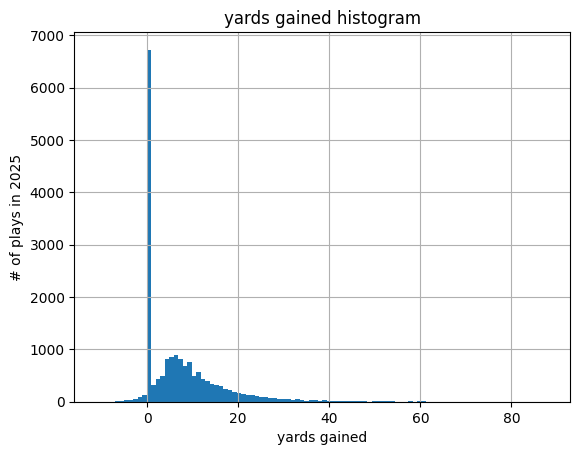

In [34]:
# The mode of yards gained is 0 by a long shot
df["yards_gained"].hist(bins = 100)
plt.title("yards gained histogram")
plt.xlabel("yards gained")
plt.ylabel("# of plays in 2025")

Text(0, 0.5, '# of plays in 2025')

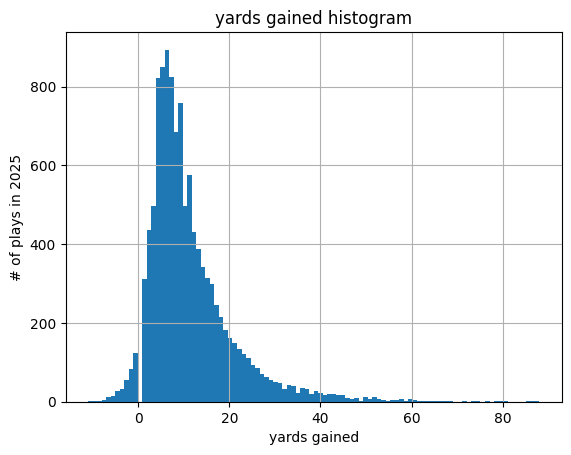

In [35]:
# excluding 0, the yards gained distribution looks normal
# it has a long right tail which makes sense for football but it is not extreme enough to cause concern
# but we will check the normality of residuals after fitting a model to be sure
df[df["yards_gained"]!=0]["yards_gained"].hist(bins = 100)
plt.title("yards gained histogram")
plt.xlabel("yards gained")
plt.ylabel("# of plays in 2025")

In [36]:
# the mean of the above pictured distribution is 11.11 yards, its standard deviation is 9.65 yards
# the min of -11 and the max of 88 yards both make sense and so do all otther metrics, there is no cause to remove data
df[df["yards_gained"]!=0]["yards_gained"].describe()

count    11566.000000
mean        11.117413
std          9.654277
min        -11.000000
25%          5.000000
50%          9.000000
75%         15.000000
max         88.000000
Name: yards_gained, dtype: float64

Text(0, 0.5, '# of plays in 2025')

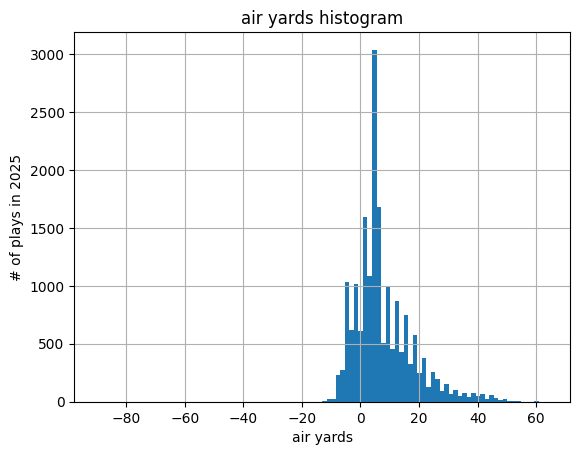

In [37]:
# the distribution of air yards is right skewed with many sipikes and a long tail
df["air_yards"].hist(bins = 100)
plt.title("air yards histogram")
plt.xlabel("air yards")
plt.ylabel("# of plays in 2025")

In [38]:
# the min and max of air_yards seen bellow is plausible
# there is no cause to remove data
df["air_yards"].describe()

count    18288.000000
mean         7.844379
std         10.172196
min        -90.000000
25%          2.000000
50%          5.000000
75%         13.000000
max         64.000000
Name: air_yards, dtype: float64

Text(0, 0.5, '# of plays in 2025')

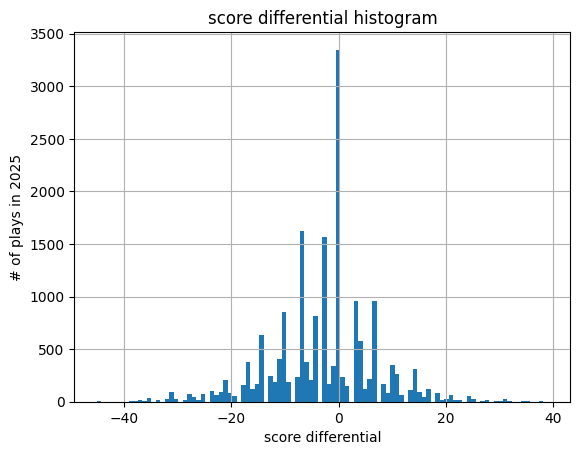

In [39]:
# score differential is score of team with possesion - score of opposing team, unsurprisingly the most common score differential is 0
# this distribution has many spikes which is expected because of the nature of scoring in football, there is no cause to remove data
df["score_differential"].hist(bins = 100)
plt.title("score differential histogram")
plt.xlabel("score differential")
plt.ylabel("# of plays in 2025")

In [40]:
#TODO: Ask ben if this is sensible
df["score_differential"].describe()

count    18288.000000
mean        -2.843176
std          9.961363
min        -45.000000
25%         -8.000000
50%         -3.000000
75%          3.000000
max         39.000000
Name: score_differential, dtype: float64

In [41]:
# the means here are all sensible, there is no cause to remove data
df[["incomplete_pass", "complete_pass","interception","penalty","touchdown","out_of_bounds"]].describe()

,incomplete_pass,complete_pass,interception,penalty,touchdown,out_of_bounds
count,18288.000000,18288.000000,18288.000000,18288.000000,18288.000000,18288.000000
mean,0.335357,0.642443,0.022200,0.014381,0.048666,0.135717
std,0.472128,0.479294,0.147339,0.119059,0.215174,0.342498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [42]:
# a pass is eaither short or deep and a short pass is way more common than a deep pass, this distribution makes sense and there is no cause to remove data
df["pass_length"].value_counts()

pass_length
short    14862
deep      3426
Name: count, dtype: int64

## 2. Linear Regression Analytical Tasks

In [43]:
# check multicollinearity before building linear model
# there is very high multicollinearity between incomplete_pass and complete_pass
# incomplete_pass, complete_pass, and interception are mutually exclusive outcomes of a pass play, so this makes sense0\
# we will drop incomlete_pass for our model
df.corr(numeric_only=True)

,quarter_seconds_remaining,yards_gained,air_yards,score_differential,incomplete_pass,interception,penalty,touchdown,complete_pass,out_of_bounds
quarter_seconds_remaining,1.000000,0.021797,-0.045928,0.059707,-0.045008,-0.004759,-0.008360,-0.012402,0.045798,-0.000020
yards_gained,0.021797,1.000000,0.256751,0.033991,-0.533394,-0.113147,0.003033,0.206497,0.560201,0.207529
air_yards,-0.045928,0.256751,1.000000,-0.004686,0.244378,0.099176,-0.022399,0.061597,-0.271212,-0.053111
score_differential,0.059707,0.033991,-0.004686,1.000000,-0.002788,-0.027894,0.002525,0.016288,0.011321,0.009549
incomplete_pass,-0.045008,-0.533394,0.244378,-0.002788,1.000000,-0.107032,-0.012840,-0.160659,-0.952147,-0.276070
interception,-0.004759,-0.113147,0.099176,-0.027894,-0.107032,1.000000,0.044145,0.021115,-0.201976,0.024814
penalty,-0.008360,0.003033,-0.022399,0.002525,-0.012840,0.044145,1.000000,0.013236,-0.000922,-0.002271
touchdown,-0.012402,0.206497,0.061597,0.016288,-0.160659,0.021115,0.013236,1.000000,0.151766,-0.087400
complete_pass,0.045798,0.560201,-0.271212,0.011321,-0.952147,-0.201976,-0.000922,0.151766,1.000000,0.264315
out_of_bounds,-0.000020,0.207529,-0.053111,0.009549,-0.276070,0.024814,-0.002271,-0.087400,0.264315,1.000000


In [44]:
# to check other assumptions of linear regression we need a test train split
# We will not check independance as plays in a football game depend only on the current state of the game so our data is independant by nature.
df_train, df_test = train_test_split(df, test_size = 0.2, random_state = 425)

In [45]:
# forward_selection function that takes in a dataframe, a list of predictors, and a target variable and returns the model selected by forward selection
def forward_selection(df, predictors, target):
    fit = target + "~1"
    current_model = smf.ols(formula=fit, data=df).fit()
    while (True):
        current_adj_r2 = current_model.rsquared_adj
        new_adj_r2s = [smf.ols(formula=fit+"+"+predictor, data=df_train).fit().rsquared_adj for predictor in predictors]
        best_adj_r2 = max(new_adj_r2s) if new_adj_r2s else current_adj_r2
        if best_adj_r2 > current_adj_r2:
            best_predictor = predictors[new_adj_r2s.index(best_adj_r2)]
            fit += "+" + best_predictor
            current_model = smf.ols(formula=fit, data=df).fit()
            predictors.remove(best_predictor)
        else:
            break
    return current_model

In [46]:
# forward selction 
forward_selection_model = forward_selection(df_train, ["quarter_seconds_remaining", "score_differential", "air_yards", "complete_pass","interception","penalty","touchdown","out_of_bounds","pass_length"], "yards_gained")
print(forward_selection_model.summary())

                            OLS Regression Results                            
Dep. Variable:           yards_gained   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     1679.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:02:39   Log-Likelihood:                -48269.
No. Observations:               14630   AIC:                         9.656e+04
Df Residuals:                   14620   BIC:                         9.663e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Text(0, 0.5, 'residuals')

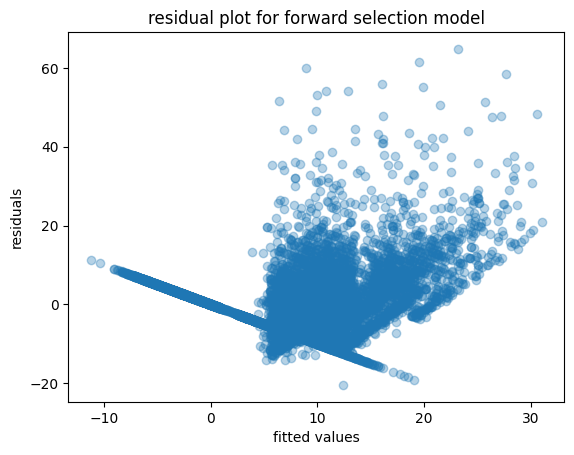

In [47]:
# model selected from forward selection uses all predictors
# we will now chek the residual plot to check equal vrience
plt.scatter(forward_selection_model.predict(df_train), df_train["yards_gained"] - forward_selection_model.predict(df_train), alpha = 0.33)
plt.title("residual plot for forward selection model")
plt.xlabel("fitted values")
plt.ylabel("residuals")

In [48]:
# the plot above hows 2 distinct patterns, a line and a cloud of points
# perhaps there is an intertion term being missed
# we now perfor forward selection with all 2 way interaction terms between quantitative and categorical variables included as predictors
# forward selction 
predictors = [ "score_differential", "score_differential:interception", "score_differential:penalty", "score_differential:touchdown", "score_differential:complete_pass", "score_differential:out_of_bounds", "score_differential:pass_length",
              "air_yards", "air_yards:interception", "air_yards:penalty", "air_yards:touchdown", "air_yards:complete_pass", "air_yards:out_of_bounds", "air_yards:pass_length",
              "quarter_seconds_remaining", "quarter_seconds_remaining:interception", "quarter_seconds_remaining:penalty", "quarter_seconds_remaining:touchdown", "quarter_seconds_remaining:complete_pass", "quarter_seconds_remaining:out_of_bounds", "quarter_seconds_remaining:pass_length",
              "interception", "penalty", "touchdown", "complete_pass", "out_of_bounds", "pass_length" ]
forward_selection_model2 = forward_selection(df_train, predictors, "yards_gained")
print(forward_selection_model2.summary())

                            OLS Regression Results                            
Dep. Variable:           yards_gained   R-squared:                       0.712
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     2127.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:02:45   Log-Likelihood:                -44349.
No. Observations:               14630   AIC:                         8.873e+04
Df Residuals:                   14612   BIC:                         8.887e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

Text(0, 0.5, 'residuals')

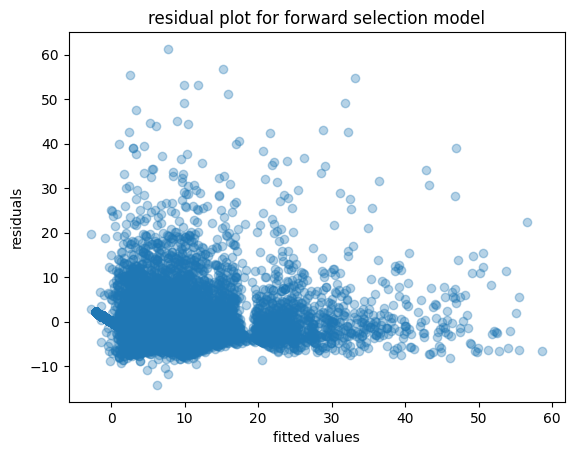

In [49]:
# model selected from forward selection uses 17 predictors
# we will now chek the residual plot to check equal vrience
plt.scatter(forward_selection_model2.predict(df_train), df_train["yards_gained"] - forward_selection_model2.predict(df_train), alpha = 0.33)
plt.title("residual plot for forward selection model")
plt.xlabel("fitted values")
plt.ylabel("residuals")

Text(0.5, 1.0, 'QQ plot of residuals for forward selection model with interaction terms')

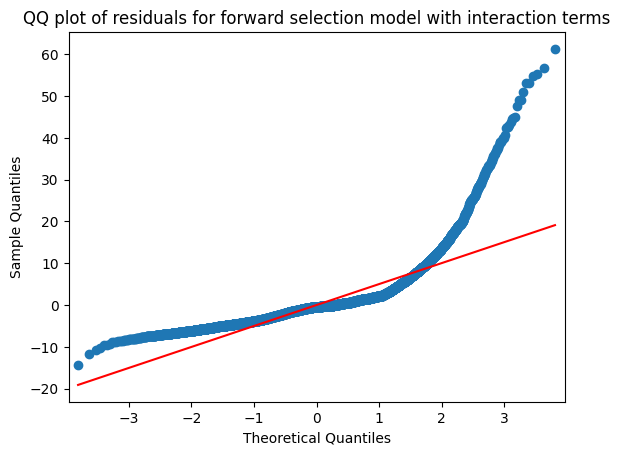

In [50]:
# with the interaction terms the selected model has R^2 of 0.709 
# the equal varience assumption looks meet
# now we check for normality of residuals with a qq plot
sm.qqplot(forward_selection_model2.resid, line='s')
plt.title("QQ plot of residuals for forward selection model with interaction terms") 

Text(0, 0.5, 'yards gained')

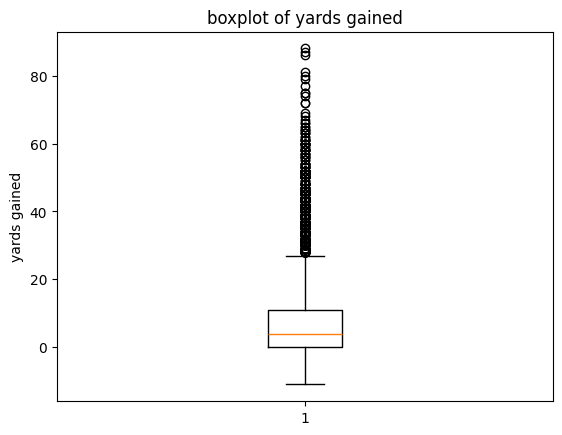

In [51]:
# the deviation of residuals from the normal line appears to be at high fitted values
# perhaps getting rid of outliers will help, lets visualize the outliers first
plt.boxplot(df["yards_gained"])
plt.title("boxplot of yards gained")
plt.ylabel("yards gained") 

In [52]:
df["yards_gained"].quantile(0.75) + 1.5*(df["yards_gained"].quantile(0.75) - df["yards_gained"].quantile(0.25))

np.float64(27.5)

In [53]:
# there appear to be a large number of outliers above the mean and none bellow, this is consistent with the right tail we saw in the histogram of yards gained
# we will now remove outliers above the Q3+1.5*IQR and refit the model to see if normality of residuals improves
linear_df = df[df["yards_gained"] <= df["yards_gained"].quantile(0.75) + 1.5*(df["yards_gained"].quantile(0.75) - df["yards_gained"].quantile(0.25))]
linear_df_train, linear_df_test = train_test_split(linear_df, test_size = 0.2, random_state = 425)
predictors = [ "score_differential", "score_differential:interception", "score_differential:penalty", "score_differential:touchdown", "score_differential:complete_pass", "score_differential:out_of_bounds", "score_differential:pass_length",
              "air_yards", "air_yards:interception", "air_yards:penalty", "air_yards:touchdown", "air_yards:complete_pass", "air_yards:out_of_bounds", "air_yards:pass_length",
              "quarter_seconds_remaining", "quarter_seconds_remaining:interception", "quarter_seconds_remaining:penalty", "quarter_seconds_remaining:touchdown", "quarter_seconds_remaining:complete_pass", "quarter_seconds_remaining:out_of_bounds", "quarter_seconds_remaining:pass_length",
              "interception", "penalty", "touchdown", "complete_pass", "out_of_bounds", "pass_length" ]
forward_selection_model3 = forward_selection(linear_df_train, predictors, "yards_gained") 
print(forward_selection_model3.summary())

                            OLS Regression Results                            
Dep. Variable:           yards_gained   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     8516.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:02:46   Log-Likelihood:                -38102.
No. Observations:               14059   AIC:                         7.621e+04
Df Residuals:                   14054   BIC:                         7.625e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

Text(0, 0.5, 'residuals')

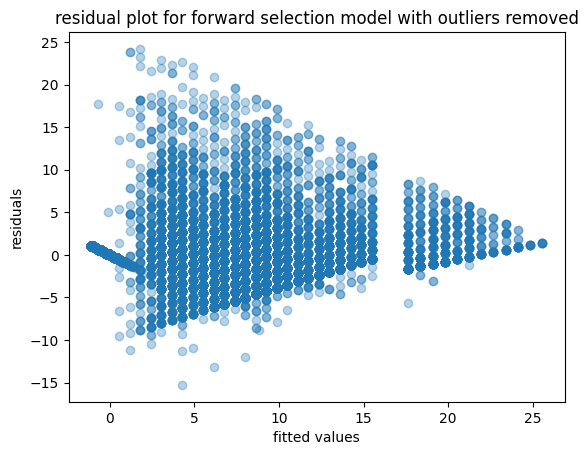

In [54]:
# resulting model has R^2 of 0.708, lets check the residual plot again to see if equal varience is still met
plt.scatter(forward_selection_model3.predict(linear_df_train), linear_df_train["yards_gained"] - forward_selection_model3.predict(linear_df_train), alpha=0.33)
plt.title("residual plot for forward selection model with outliers removed")
plt.xlabel("fitted values")
plt.ylabel("residuals")

Text(0.5, 1.0, 'QQ plot of residuals for forward selection model with interaction terms and outliers removed')

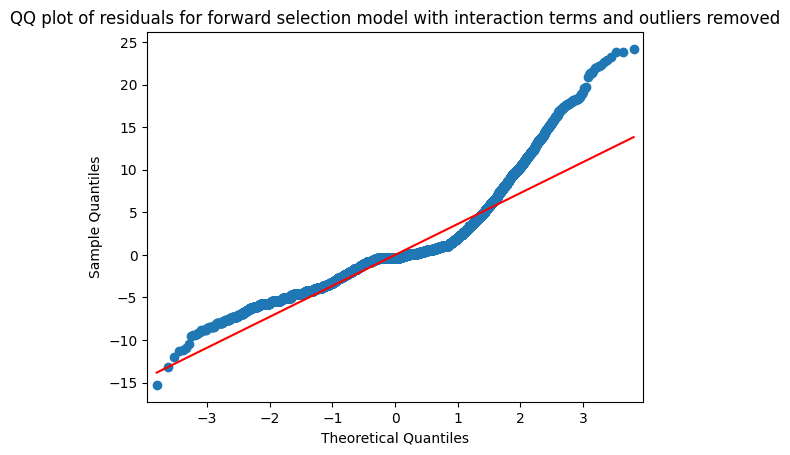

In [55]:
# quite interestingly we see higher varience at lower fitted values, but this is still acceptable
# lets see if the normality of residuals has improved with a qq plot
sm.qqplot(forward_selection_model3.resid, line='s')
plt.title("QQ plot of residuals for forward selection model with interaction terms and outliers removed")

In [56]:
# The qq plot looks much better, the residuals are much closer to the normal line
# Thus the final model we choose is forward_selection_model3, the forward selection model with interaction terms and outliers removed
print(forward_selection_model3.summary())

                            OLS Regression Results                            
Dep. Variable:           yards_gained   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     8516.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:02:46   Log-Likelihood:                -38102.
No. Observations:               14059   AIC:                         7.621e+04
Df Residuals:                   14054   BIC:                         7.625e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

# FINAL MODEL:

yards_gained = 0.3219 + 5.8266(complete_pass) + 0.7164(air_yards)(complete_pass) + 0.0020(air_yards)(pass_length[deep]) - 0.0946(air_yards)(pass_length[short])

from all the analysis performed it is ok to conclude that this model is not perfect but good for predicting yards_gained and that the following results are valid:

95% confidence intervals for slopes in our final model can be found in the table above as:
1. air_yards:complete_pass -> (0.701, 0.732)
2. air_yard:pass_length[deep] -> (-0.006, 0.010)
3. air_yard:pass_length[short] -> (-0.110, 0.079)

## Interpritation:

These slopes tell us that you gain the most yards in a play with a complete pass with the most air_yards and a deep pass is better than a shallow pass.

In [57]:
# granted this model is valid, lets assess its performance on the test set
test_r2 = r2_score(linear_df_test["yards_gained"], forward_selection_model3.predict(linear_df_test))
print(f" r2 with test dataset: {test_r2}")

 r2 with test dataset: 0.7130842209656665


In [59]:
test_rmse = (((linear_df_test["yards_gained"] - forward_selection_model3.predict(linear_df_test))**2).mean()**0.5)
print(f" rmse with test dataset: {test_rmse}")

 rmse with test dataset: 3.620376779510299


# Model Evaluation:

this model made to predict yards_gaained by the state of the game can explain 71.3% (this R^2 is fairly high) of the variation in yards_gained in a certaion play with 4 variables. It is typicaly off by 3.62 yards (this RMSE is fairly low). Overall this is a good model. 

## 3. Logistic Regression Analytical Tasks

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

## 4. Conclusion

## AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class.  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.